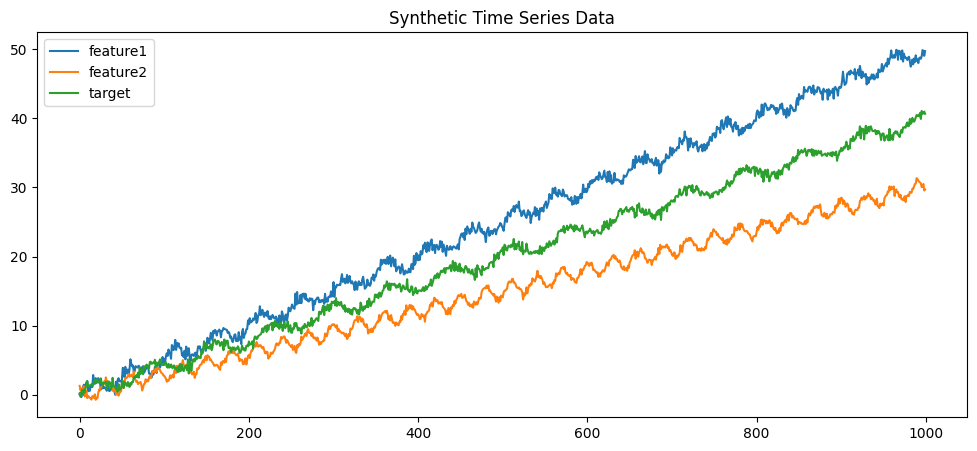

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 0.2263 - mse: 0.0968 - val_loss: 0.0848 - val_mse: 0.0078
Epoch 2/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0318 - mse: 0.0015 - val_loss: 0.0336 - val_mse: 0.0016
Epoch 3/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0207 - mse: 6.6806e-04 - val_loss: 0.0182 - val_mse: 4.5940e-04
Epoch 4/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0202 - mse: 5.8613e-04 - val_loss: 0.0207 - val_mse: 6.3482e-04
Epoch 5/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0198 - mse: 5.7688e-04 - val_loss: 0.0321 - val_mse: 0.0015
Epoch 6/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0210 - mse: 6.5028e-04 - val_loss: 0.0338 - val_mse: 0.0016
Epoch 7/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0192 - mse: 5.4670e-04 - val_loss: 0.0226 - val_mse: 7.6274e-04
Epoch 8/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0199 - mse: 5.8614e-04 - val_loss: 0.0195 - val_mse: 5.1924e-04
Epoch 9/20
22/22 ━━━━━━━━━━━━━━━━━━

  0%|          | 0/3 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
6775/6775 ━━━━━━━━━━━━━━━━━━━━ 37s 6ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
6775/6775 ━━━━━━━━━━━━━━━━━━━━ 38s 6ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
6775/6775 ━━━━━━━━━━━━━━━━━━━━ 38s 6ms/step

SHAP Waterfall Plot for Event 1


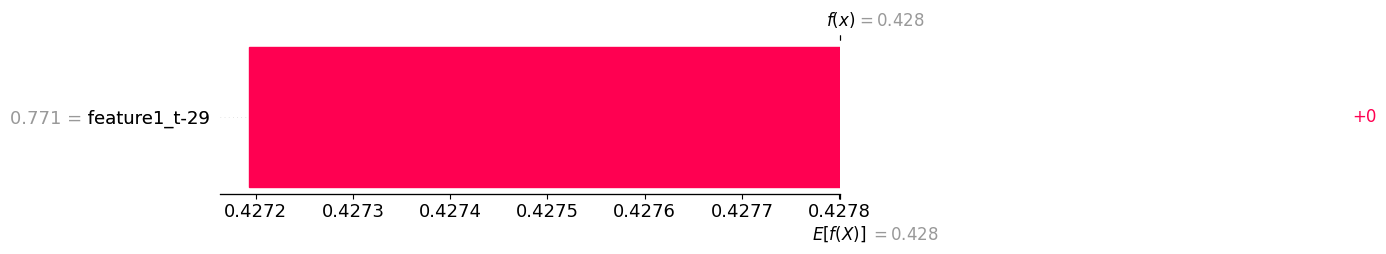


SHAP Waterfall Plot for Event 2


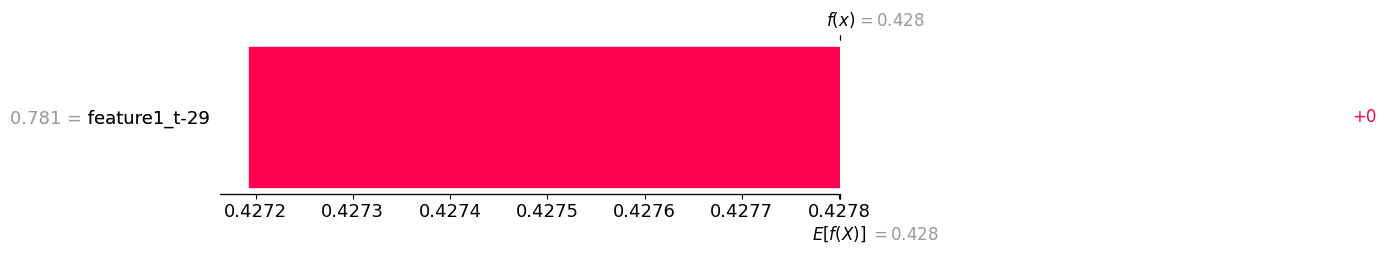


SHAP Waterfall Plot for Event 3


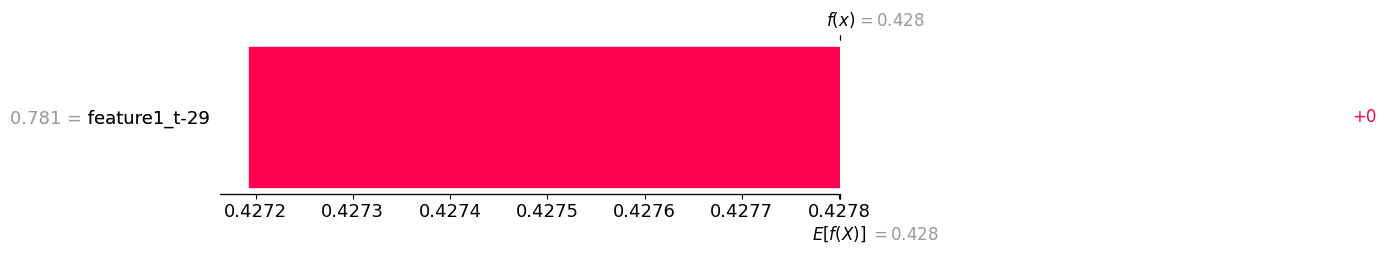

In [5]:
# 🛖 Install dependencies
!pip install shap pandas scikit-learn statsmodels tensorflow matplotlib

# 📊 1. Generate Synthetic Multivariate Time Series Data
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def generate_dataset(n_obs=1000):
    t = np.arange(n_obs)
    data = {
        'feature1': np.sin(2 * np.pi * t / 50) + 0.05 * t + np.random.normal(0, 0.5, n_obs),
        'feature2': np.cos(2 * np.pi * t / 30) + 0.03 * t + np.random.normal(0, 0.3, n_obs),
        'target': np.sin(2 * np.pi * t / 70) + 0.04 * t + np.random.normal(0, 0.4, n_obs)
    }
    return pd.DataFrame(data)

df = generate_dataset()
df.plot(title="Synthetic Time Series Data", figsize=(12, 5))
plt.show()

# 🔄 2. Normalize, Window, Split
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

scaler = MinMaxScaler()
scaled = scaler.fit_transform(df)

def create_sequences(data, window_size=30):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i+window_size, :-1])
        y.append(data[i+window_size, -1])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# 🧠 3. LSTM Model
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model = Sequential([
    LSTM(64, input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=False),
    Dense(1)
])
model.compile(optimizer='adam', loss='mae', metrics=['mse'])
model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.1)

# 📈 4. Evaluate LSTM
from sklearn.metrics import mean_absolute_error, mean_squared_error

y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"LSTM MAE: {mae:.4f}, RMSE: {rmse:.4f}")

# 📉 5. ARIMA Baseline
from statsmodels.tsa.arima.model import ARIMA

arima_model = ARIMA(df['target'], order=(5,1,0)).fit()
arima_pred = arima_model.predict(start=len(df)-len(y_test), end=len(df)-1)
arima_mae = mean_absolute_error(y_test, arima_pred)
arima_rmse = np.sqrt(mean_squared_error(y_test, arima_pred))
print(f"ARIMA MAE: {arima_mae:.4f}, RMSE: {arima_rmse:.4f}")

# 🔍 6. SHAP Explainability
import shap

# Get window size and number of features from X_train shape
window_size = X_train.shape[1]
num_features = X_train.shape[2]

# 1. Define a wrapper prediction function for the model
# This function takes a 2D input (n_samples, flattened_features) and reshapes it
# to 3D (n_samples, window_size, n_features) for the LSTM model.
def predictor_wrapper(inp_flat):
    reshaped_inp = inp_flat.reshape(-1, window_size, num_features)
    return model.predict(reshaped_inp)

# 2. Create a background dataset
# KernelExplainer needs a background dataset to estimate expected values.
# It's typically a small, representative sample of the training data.
# Choose a subset of X_train to keep the computation manageable, and flatten it.
if X_train.shape[0] > 100:
    background_3d = X_train[np.random.choice(X_train.shape[0], 100, replace=False)]
else:
    background_3d = X_train
background_flat = background_3d.reshape(background_3d.shape[0], -1)

# 3. Initialize shap.KernelExplainer with the wrapper and flattened background
explainer = shap.KernelExplainer(predictor_wrapper, background_flat)

# 4. Calculate SHAP values for the test events
# Flatten the test instances before passing to shap_values
X_test_flat = X_test[:3].reshape(X_test[:3].shape[0], -1)
shap_values_list = explainer.shap_values(X_test_flat)

# Extract the actual SHAP values array for our single output model
shap_values_array = shap_values_list[0]

# 5. Prepare flattened feature names for plotting
original_feature_names = df.columns[:-1].tolist() # e.g., ['feature1', 'feature2']
flattened_feature_names = []
for i in range(window_size): # iterate from oldest to newest time step
    for name in original_feature_names:
        # Name features like 'feature1_t-29', 'feature2_t-29', ..., 'feature1_t-0', 'feature2_t-0'
        flattened_feature_names.append(f"{name}_t-{window_size-1-i}")

# 6. Plot SHAP waterfall plots for each event
for i in range(3):
    print(f"\nSHAP Waterfall Plot for Event {i+1}")
    # shap.Explanation object helps structure the data for plotting
    # base_values will be a scalar for a single output model
    shap_explanation = shap.Explanation(values=shap_values_array[i],
                                         base_values=explainer.expected_value[0],
                                         data=X_test_flat[i], # Use flattened data for the explanation object
                                         feature_names=flattened_feature_names)

    shap.plots.waterfall(shap_explanation)